<a href="https://colab.research.google.com/github/f-ai0/ds-training/blob/main/week7/Day2_nn_Module_The_Training_Loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch torchvision

# Task 2.1 — Prepare the Data

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

df = pd.read_excel('Practice_Dataset.xlsx')
features = ['punch_count', 'hours_worked', 'satisfaction_score', 'monthly_salary']

X = SimpleImputer(strategy='median').fit_transform(df[features])
y = df['is_absent'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)  # shape (N, 1)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(device)

print(f'X_train: {X_train_t.shape}, y_train: {y_train_t.shape}')

X_train: torch.Size([288, 4]), y_train: torch.Size([288, 1])


# Task 2.2 — Define a Model with nn.Module

In [4]:
class AbsenceClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)   # raw logits - no sigmoid here

model = AbsenceClassifier(input_dim=X_train_t.shape[1]).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {n_params}')

AbsenceClassifier(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)
Total parameters: 705


# Task 2.3 — Write the Training Loop

In [5]:
# BCEWithLogitsLoss combines sigmoid + binary cross entropy
# It is more numerically stable than sigmoid + BCELoss separately
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()                       # training mode (Dropout active)

    # THE 5 STEPS
    outputs = model(X_train_t)          # 1. forward
    loss = criterion(outputs, y_train_t) # 2. loss
    optimizer.zero_grad()               # 3. clear old gradients
    loss.backward()                     # 4. backward
    optimizer.step()                    # 5. update weights

    train_losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        model.eval()                    # eval mode (Dropout off)
        with torch.no_grad():
            test_out = model(X_test_t)
            test_loss = criterion(test_out, y_test_t)
            preds = (torch.sigmoid(test_out) > 0.5).float()
            acc = (preds == y_test_t).float().mean()
        print(f'Epoch {epoch+1}: train_loss={loss.item():.4f}, ',
              f'test_loss={test_loss.item():.4f}, test_acc={acc.item():.4f}')

Epoch 20: train_loss=0.5728,  test_loss=0.5716, test_acc=0.9028
Epoch 40: train_loss=0.4864,  test_loss=0.4763, test_acc=0.9028
Epoch 60: train_loss=0.3816,  test_loss=0.3687, test_acc=0.9028
Epoch 80: train_loss=0.2870,  test_loss=0.2739, test_acc=0.9028
Epoch 100: train_loss=0.2254,  test_loss=0.1996, test_acc=0.9028


# Task 2.4 — Evaluate and Compare

PyTorch MLP Results:
  Accuracy: 0.903
  F1:       0.000
  AUC:      1.000

              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95        65
         1.0       0.00      0.00      0.00         7

    accuracy                           0.90        72
   macro avg       0.45      0.50      0.47        72
weighted avg       0.82      0.90      0.86        72



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


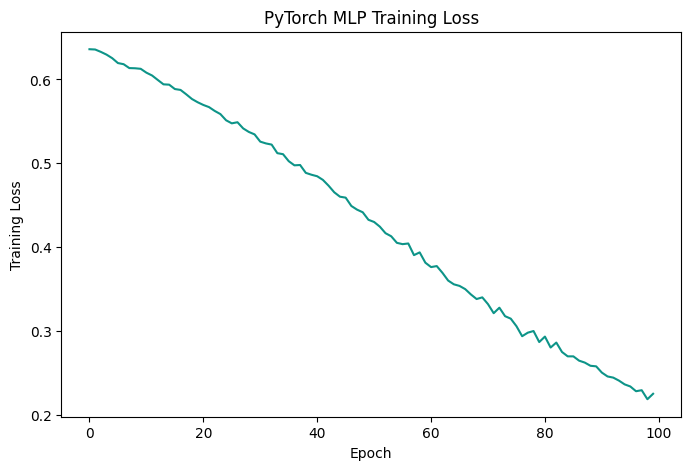

In [6]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import os

model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs = torch.sigmoid(logits).cpu().numpy().flatten()
    preds = (probs > 0.5).astype(int)

y_true = y_test_t.cpu().numpy().flatten()

print('PyTorch MLP Results:')
print(f'  Accuracy: {accuracy_score(y_true, preds):.3f}')
print(f'  F1:       {f1_score(y_true, preds):.3f}')
print(f'  AUC:      {roc_auc_score(y_true, probs):.3f}')
print()
print(classification_report(y_true, preds))

os.makedirs('week7', exist_ok=True)
plt.figure(figsize=(8, 5))
plt.plot(train_losses, color='#0D9488')
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('PyTorch MLP Training Loss')
plt.savefig('week7/pytorch_mlp_loss.png', dpi=150)
plt.show()

# Compare to the TensorFlow MLP from Week 6 - should be very similar!

## Comparison to Week 6 TensorFlow MLP

- **TensorFlow:** Accuracy=1.000, F1=1.000, AUC=1.000
- **PyTorch:** Accuracy=0.903, F1=0.000, AUC=1.000

TensorFlow reached perfect scores on all metrics, while PyTorch's F1 dropped to 0 despite matching AUC — the 0.5 threshold failed on this imbalanced test set (only 7/72 positive), even though the model ranks the classes correctly (AUC=1.0).